<a href="https://www.kaggle.com/code/boredanalystlouis/employability-model-with-pca-and-decision-tree?scriptVersionId=301537222" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anashamoutni/students-employability-dataset/Student-Employability-Datasets.xlsx


# DESCRIPTION #

This research project identifies the variables that can be used to predict a students' employability. The dataset is of Philippine University students who underwent mock interviews along with their scores on various rubrics. There were originally seven categories / variables. After a Principal Component Analysis (PCA) to reduce the variables down to three. The three variables (Cognitive Clarity, Appearance, and Overall Performance) captured at least 80% of the original variance.

# MODELS USED #

This project used a Decision Tree using these three variables and the result column of the dataset telling whether a student is Employable or Less Employable. The decision tree was done multiple times to identify the optimum tree depth. At the end, the Decision Tree was pruned at a maximum depth of 8; this point retains an ~85% accuracy score. Any further lengthening of the tree shows diminishing returns. 

In [2]:
## importing the data

df = pd.read_excel("/kaggle/input/datasets/anashamoutni/students-employability-dataset/Student-Employability-Datasets.xlsx")

In [3]:
df.head(3)

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable


# DATA PREPROCESSING #

## Data Cleaning and Transformation ##

In [4]:
## renaming the columns

df = df.rename(columns={
    "Name of Student":"student_name",
    "GENERAL APPEARANCE":"general_appearance",
    "MANNER OF SPEAKING":"manner_of_speaking",
    "PHYSICAL CONDITION":"physical_condition",
    "MENTAL ALERTNESS":"mental_alertness",
    "SELF-CONFIDENCE":"self_confidence",
    "ABILITY TO PRESENT IDEAS":"ability_to_present_ideas",
    "COMMUNICATION SKILLS":"communication_skills",
    "Student Performance Rating":"student_performance_rating",
    "CLASS":"class"
})

df.head(2)

,student_name,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,communication_skills,student_performance_rating,class
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable


In [5]:
## adding a numeric column

df["result_numeric"] = df["class"].map({
    "Employable":1,
    "LessEmployable":0
})

In [6]:
## scanning the columns for information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   student_name                2982 non-null   object
 1   general_appearance          2982 non-null   int64 
 2   manner_of_speaking          2982 non-null   int64 
 3   physical_condition          2982 non-null   int64 
 4   mental_alertness            2982 non-null   int64 
 5   self_confidence             2982 non-null   int64 
 6   ability_to_present_ideas    2982 non-null   int64 
 7   communication_skills        2982 non-null   int64 
 8   student_performance_rating  2982 non-null   int64 
 9   class                       2982 non-null   object
 10  result_numeric              2982 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 256.4+ KB


In [7]:
## summarizing the columns 

df.describe()

,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,communication_skills,student_performance_rating,result_numeric
count,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000
mean,4.246814,3.884641,3.972166,3.962777,3.910798,3.813883,3.525486,4.610664,0.579812
std,0.678501,0.757013,0.744135,0.781982,0.807602,0.739390,0.743881,0.692845,0.493672
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,0.000000
25%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,0.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,1.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


## Data Reduction - PCA ##

In [8]:
## standardizing the data

from sklearn.preprocessing import StandardScaler

df_x = df.select_dtypes(include=[float, int])
df_x = df_x.drop("result_numeric", axis="columns")

## create the scaler

scaler = StandardScaler()
scaled_x = scaler.fit_transform(df_x)

scaled_x = pd.DataFrame(scaled_x, columns=df_x.columns)
scaled_x.head(5)

,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,communication_skills,student_performance_rating
0,-0.363825,1.473616,0.037410,1.326626,1.348912,1.604452,1.982523,0.562033
1,-0.363825,0.152412,0.037410,0.047609,0.110471,0.251759,-0.706530,0.562033
2,-0.363825,-1.168791,-1.306657,-1.231407,-1.127970,-1.100934,-2.051057,0.562033
3,-1.837909,-1.168791,-1.306657,-2.510424,-1.127970,-1.100934,-0.706530,0.562033
4,-0.363825,0.152412,-1.306657,-1.231407,0.110471,0.251759,-0.706530,0.562033


In [9]:
## fitting the PCA

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_x)


## returning the values of the pca

print(pca.explained_variance_ratio_)

## explaining the variance of the PCs

cum_var = np.cumsum(pca.explained_variance_ratio_)
print("CUMULATIVE VARIANCE:")
print(cum_var)

[0.5526148  0.1379806  0.08298072 0.06597389 0.05074906 0.04109003
 0.03707099 0.03153991]
CUMULATIVE VARIANCE:
[0.5526148  0.6905954  0.77357612 0.83955001 0.89029907 0.9313891
 0.96846009 1.        ]


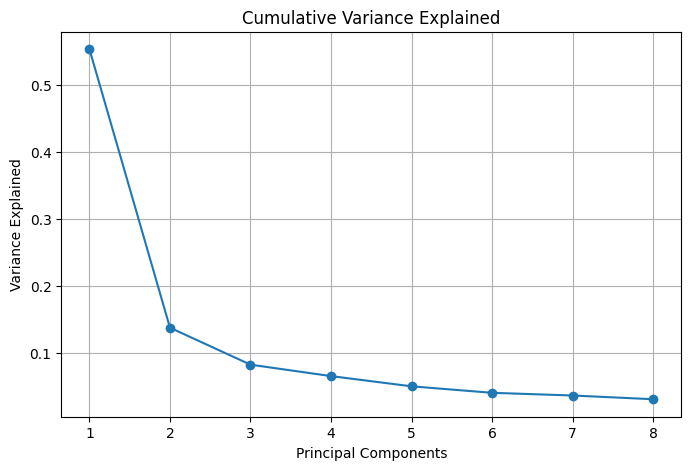

In [10]:
## plotting the scree plot for the cumulative variance


df_y = pca.explained_variance_ratio_
df_x = range(1, len(df_y) + 1)



plt.figure(figsize=(8,5))
plt.plot(df_x, df_y, marker="o")

## annotating the chart

plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Cumulative Variance Explained")
plt.grid(True)
plt.show()

In [11]:
### reducing the dataframe using the principal components

pca = PCA(n_components = 3)
df_reduced = pca.fit_transform(scaled_x)

## getting the loadings of a pca

principal_columns = ["cognitive_clarity", "overall_performance", "appearance"]
loadings = pd.DataFrame(pca.components_.T, index = scaled_x.columns, columns = principal_columns)
loadings

df_reduced = pd.DataFrame(df_reduced, columns= loadings.columns)

## recombining the columns

df_reduced["result_numeric"] = df["result_numeric"]
df_reduced["student_name"] = df["student_name"]
df_reduced = df_reduced[["student_name","cognitive_clarity","appearance","overall_performance","result_numeric"]]
df_reduced.head(5)

,student_name,cognitive_clarity,appearance,overall_performance,result_numeric
0,Student 1,2.944651,-1.461929,1.022443,1
1,Student 2,-0.119563,0.149061,0.622146,1
2,Student 3,-3.185530,0.954074,0.391126,0
3,Student 4,-3.640819,-0.698435,0.927134,0
4,Student 5,-1.147776,-0.183229,0.694427,1


# LOGISTIC REGRESSION #

In [12]:
from sklearn.model_selection import train_test_split

df_x = df_reduced[["cognitive_clarity","appearance","overall_performance"]]
df_y = df_reduced["result_numeric"]

df_x_train, df_x_test, df_y_train, df_y_test = train_test_split(df_x, df_y,test_size=0.2, random_state=42)

### Building the logistic regression model

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(df_x_train, df_y_train)


print("THE RESULTS")
print(f'Logistic Regression Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

THE RESULTS
Logistic Regression Coefficients: [[ 0.18802375 -0.01288699 -0.02445322]]
Intercept: [0.35960081]


### Predicting using logistic regression ###



In [14]:
df_y_predicted = model.predict(df_x_test)

### Evaluating the performance of the Logistic Regression model

In [15]:
## importing accuracy score

from sklearn.metrics import accuracy_score

results = accuracy_score(df_y_test, df_y_predicted)
results

0.542713567839196

### Creating a confusion matrix

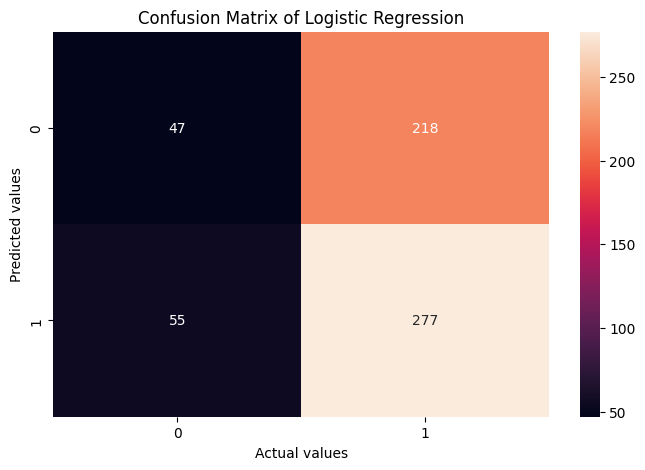

In [16]:
from sklearn.metrics import confusion_matrix

confusion_corr = confusion_matrix(df_y_test, df_y_predicted)

## plotting the heatmmap

plt.figure(figsize=(8,5))
sns.heatmap(confusion_corr, fmt="d", annot=True)
plt.title("Confusion Matrix of Logistic Regression")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

## CREATING A DECISION TREE ##

## Preparing the inputs ##

In [17]:
from sklearn.model_selection import train_test_split

df_x = df_reduced[["cognitive_clarity","appearance","overall_performance"]]
df_y = df_reduced["result_numeric"]

df_x_train, df_x_test, df_y_train, df_y_test = train_test_split(df_x, df_y,test_size=0.2, random_state=42)

### Setting up the model ###

In [18]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(df_x, df_y)

DecisionTreeClassifier(max_depth=6, random_state=42)

### Predicting with the decision model ###

In [19]:
## this is a sample prediction

from sklearn.metrics import accuracy_score

df_y_predicted = clf.predict(df_x_test)

accuracy_results = accuracy_score(df_y_test, df_y_predicted)
accuracy_results

0.7671691792294807

### Finding the sweet spot for decision tree classifier tree score ###




In [20]:
accuracy_scores = []

for num in range(2,20):
    clf = DecisionTreeClassifier(max_depth=num, random_state=42)
    clf.fit(df_x, df_y)
    df_y_pred = clf.predict(df_x_test)
    result = accuracy_score(df_y_test, df_y_pred)
    accuracy_scores.append(result)

## returning the results 
max_tree_depth = np.arange(2,20)

tree_results = pd.DataFrame(
    {
        "max_tree_depth":max_tree_depth,
        "accuracy_scores":accuracy_scores
    }
)

tree_results

,max_tree_depth,accuracy_scores
0,2,0.644891
1,3,0.644891
2,4,0.678392
3,5,0.743719
4,6,0.767169
5,7,0.785595
6,8,0.814070
7,9,0.849246
8,10,0.867672
9,11,0.877722


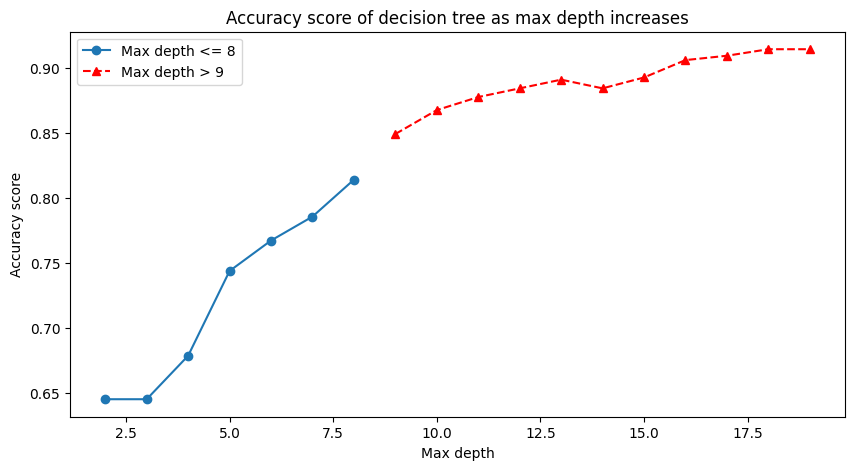

In [21]:
## Visualizing the decision tree accuracy

viz_df = tree_results[tree_results["max_tree_depth"]<=8]

viz_df_x = viz_df["max_tree_depth"]
viz_df_y = viz_df["accuracy_scores"]

## plotting the first half of the text

plt.figure(figsize=(10,5))
plt.plot(viz_df_x, viz_df_y, marker="o", label="Max depth <= 8")
plt.title("Accuracy score of decision tree as max depth increases")
plt.ylabel("Accuracy score")
plt.xlabel("Max depth")

## plotting the second half of the plot

viz_df = tree_results[tree_results["max_tree_depth"]>=9]
viz_df_x = viz_df["max_tree_depth"]
viz_df_y = viz_df["accuracy_scores"]
plt.plot(viz_df_x, viz_df_y, marker="^", linestyle="--", color="red", label="Max depth > 9")

plt.legend()

plt.show()